# Guía práctica de HAPI (HITRAN Application Programming Interface)



In [5]:
import sys
sys.path.append(r'C:\Users\PC\Documents\GitHub\Photonix\scrips\forwards\1')
import final_forward_attenuation as ffa

## 1. Instalación

Antes de ejecutar las celdas de cálculo, instala HAPI en el mismo entorno que usa este cuaderno. El paquete se publica en PyPI como `hitran-api`; se recomienda actualizar a la última versión estable para disponer de las rutas de descarga más recientes y compatibilidad con HITRAN2024.


### Requisitos previos

- **API key de HITRAN:** Registra tu cuenta en [hitran.org](https://hitran.org) y añade una clave en tu perfil. HAPI la utiliza al momento de descargar datos; el valor se solicita al ejecutar `fetch` o puede almacenarse en la variable de entorno `HITRAN_API_KEY`.

- **Conectividad a internet:** Las descargas se hacen en tiempo real; si trabajas sin red, solo podrás reutilizar tablas ya almacenadas en disco.


In [1]:
# Instala la versión oficial publicada por el equipo HITRAN
%pip install --upgrade hitran-api

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Inicialización de la base de datos local

HAPI crea un directorio para guardar las tablas descargadas en formato `.data` y `.header`. Usa `db_begin` con un nombre de carpeta para iniciar o reutilizar la base local. También se importan bibliotecas auxiliares para cálculos y gráficas.


In [2]:
# Importa HAPI y prepara una carpeta local para las tablas
from hapi import *
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
# Crea (o reutiliza) la carpeta 'hapi_db' donde se guardarán los archivos .data y .header.
db_begin('hapi_db')

Using hapi_db

CH4_333_2500
                     Lines parsed: 64453
CO2_333_2500
                     Lines parsed: 68030
CO_333_2500
                     Lines parsed: 282
H2O_333_2500
                     Lines parsed: 16963
N2O_333_2500
                     Lines parsed: 108041
O3_333_2500
                     Lines parsed: 173394


## 3. Descarga de líneas de absorción

`fetch` descarga y almacena líneas HITRAN en el rango espectral indicado. Requiere el ID de molécula (`M`) y el ID de isotopólogo (`I`), que puedes consultar en la tabla `ISO`. Esta celda también muestra cómo inspeccionar las columnas disponibles para adaptar posteriores cálculos.


In [6]:

# Configurar la API key de HITRAN
# Opción 1: Usar variable de entorno si existe, sino pedirla
import os
from getpass import getpass

hitran_api_key = os.environ.get('HITRAN_API_KEY')

if not hitran_api_key:
    print('Se requiere API key de HITRAN para descargar datos.')
    print('Obtén una en: https://hitran.org (crea cuenta → Profile → API key)')
    hitran_api_key = getpass('Ingresa tu API key de HITRAN: ')
    # Guardar en variable de entorno para esta sesión
    os.environ['HITRAN_API_KEY'] = hitran_api_key

# Configurar HAPI con la API key
from hapi import setHitranAPIKey
setHitranAPIKey(hitran_api_key)
print('✓ API key configurada correctamente')


Se requiere API key de HITRAN para descargar datos.
Obtén una en: https://hitran.org (crea cuenta → Profile → API key)


ImportError: cannot import name 'setHitranAPIKey' from 'hapi' (c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\hapi\__init__.py)

In [ ]:
# Descargar líneas HITRAN para 6 gases en el rango 333.33 - 2500 cm⁻¹
# IDs de moléculas HITRAN: H2O=1, CO2=2, O3=3, N2O=4, CO=5, CH4=6

nu_min = 333.33
nu_max = 2500.0

gases = [
    ('H2O', 1),
    ('CO2', 2),
    ('O3', 3),
    ('N2O', 4),
    ('CO', 5),
    ('CH4', 6)
]

print(f'Descargando líneas HITRAN para {nu_min:.2f} - {nu_max:.0f} cm⁻¹\n')

for nombre, mol_id in gases:
    tabla = f'{nombre}_{int(nu_min)}_{int(nu_max)}'
    try:
        print(f'  {nombre:5} (M={mol_id})...', end=' ', flush=True)
        fetch(tabla, mol_id, 1, nu_min, nu_max)
        print('✓')
    except Exception as e:
        print(f'✗ Error: {type(e).__name__}')

print('\nDescargas completadas. Tablas disponibles:')
for tabla in sorted(LOCAL_TABLE_CACHE.keys()):
    if any(gas in tabla for gas, _ in gases):
        num_lineas = len(LOCAL_TABLE_CACHE[tabla]['data']['nu'])
        print(f'  {tabla}: {num_lineas} líneas')

In [ ]:
# Descargar 6 gases directamente en una sola tabla combinada
import os
import pickle
import numpy as np

nu_min = 333.33
nu_max = 2500.0

gases = [
    ('H2O', 1),
    ('CO2', 2),
    ('O3', 3),
    ('N2O', 4),
    ('CO', 5),
    ('CH4', 6)
]

tabla_combinada = 'Mols_combined'
db_path = VARIABLES['BACKEND_DATABASE_NAME']

print(f'Descargando 6 gases y guardando en tabla única: {tabla_combinada}\n')

# Diccionario para los datos combinados
all_data = {}
total_lines = 0
ref_header = None

# Descargar y combinar directamente en un solo pass
for nombre, mol_id in gases:
    # Nombre temporal para fetch (no se guardará en disco, solo en caché)
    tabla_temp = f'_temp_{nombre}_{int(nu_min)}_{int(nu_max)}'
    
    try:
        print(f'  {nombre:5} (M={mol_id})...', end=' ', flush=True)
        fetch(tabla_temp, mol_id, 1, nu_min, nu_max)
        
        # Obtener datos del caché de HAPI
        table_data = LOCAL_TABLE_CACHE[tabla_temp]['data']
        num_lines = len(table_data['nu'])
        
        # Guardar header de la primera tabla como referencia
        if ref_header is None:
            ref_header = LOCAL_TABLE_CACHE[tabla_temp]['header'].copy()
        
        # Inicializar o concatenar datos
        if not all_data:
            all_data = {key: np.array(values) for key, values in table_data.items()}
        else:
            for key in all_data:
                if key in table_data:
                    all_data[key] = np.concatenate([all_data[key], np.array(table_data[key])])
        
        total_lines += num_lines
        print(f'✓ {num_lines:6d} líneas')
        
        # Limpiar tabla temporal del caché
        dropTable(tabla_temp)
        
    except Exception as e:
        print(f'\n✗ Error en {nombre}: {str(e)}')
        import traceback
        traceback.print_exc()
        print()

# Guardar tabla única en hapi_db
if all_data and ref_header:
    header_file = os.path.join(db_path, f'{tabla_combinada}.header')
    data_file = os.path.join(db_path, f'{tabla_combinada}.data')
    
    # Actualizar header con el total de líneas
    ref_header['number_of_rows'] = total_lines
    
    # Guardar header y data
    with open(header_file, 'wb') as f:
        pickle.dump(ref_header, f)
    
    with open(data_file, 'wb') as f:
        pickle.dump(all_data, f)
    
    file_size_mb = os.path.getsize(data_file) / 1024 / 1024
    print(f'\n✓ TABLA GUARDADA EN HAPI_DB')
    print(f'  Nombre: {tabla_combinada}')
    print(f'  Total líneas: {total_lines:,}')
    print(f'  Data file size: {file_size_mb:.2f} MB')
    print(f'  Ubicación: {data_file}')
else:
    print('\n✗ No se pudo crear la tabla combinada')
    if not all_data:
        print('  → Ningún gas se descargó correctamente')
    if not ref_header:
        print('  → No hay header de referencia')


Descargando líneas HITRAN para 333.33 - 2500 cm⁻¹

  H2O   (M=1)... 
Data is fetched from http://hitran.org

✗ Error: Exception
  CO2   (M=2)... 
Data is fetched from http://hitran.org

✗ Error: Exception
  O3    (M=3)... 
Data is fetched from http://hitran.org

✗ Error: Exception
  N2O   (M=4)... 
Data is fetched from http://hitran.org

✗ Error: Exception
  CO    (M=5)... 
Data is fetched from http://hitran.org

✗ Error: Exception
  CH4   (M=6)... 
Data is fetched from http://hitran.org

✗ Error: Exception

Descargas completadas. Tablas disponibles:
  CH4_333_2500: 64453 líneas
  CO2_333_2500: 68030 líneas
  CO_333_2500: 282 líneas
  H2O_333_2500: 16963 líneas
  N2O_333_2500: 108041 líneas
  O3_333_2500: 173394 líneas


KeyError: 'nu'

## 4. Coeficiente de absorción

`absorptionCoefficient_HT` calcula el coeficiente de absorción espectral usando el perfil Hartmann-Tran. Debes suministrar:

- `Components`: tuplas `(M, I, fracción)` que indican especie activa y su fracción molar o VMR.

- `SourceTables`: el nombre de la tabla descargada con `fetch`.

- `Environment`: diccionario con temperatura (`T`, K) y presión (`p`, atm).

- `Diluent`: mezcla de ensanchamiento (por ejemplo, aire seco a 1.0).

Los parámetros `OmegaRange` y `OmegaStep` definen el rango espectral y la resolución.


In [25]:
presion = 1.0  # 1013 mb = 1 atm
temperatura = 288.2  # K
vmr = 0.00775  # Volume Mixing Ratio de H2O (7750 ppm)
longitud_cm = 100.0  # 1 metro

print(f"Presión: {presion} atm (1013 mb)")
print(f"Temperatura: {temperatura} K")
print(f"Longitud de trayectoria: {longitud_cm} cm ({longitud_cm/100} m)")
print(f"Rango espectral: 4-9 μm (1111-2500 cm⁻¹)")

Presión: 1.0 atm (1013 mb)
Temperatura: 288.2 K
Longitud de trayectoria: 100.0 cm (1.0 m)
Rango espectral: 4-9 μm (1111-2500 cm⁻¹)


H2O

In [30]:
vmr = 0.00775
components = [(1, 1, vmr)]  
nu, coef = absorptionCoefficient_HT(
    Components=components,
    SourceTables='H2O_333_2500',
    OmegaRange=(333.33, 2500.0),  
    OmegaStep=0.01,  
    HITRAN_units=False,  
    Environment={'T': temperatura, 'p': presion},
    Diluent={'air': 1.0}
)
print(f'Estadísticas del coeficiente de absorción (cm⁻¹):')
print(f'  Mínimo: {coef.min():.6e}')
print(f'  Máximo: {coef.max():.6e}')
print(f'  Media: {coef.mean():.6e}')
print(f'  Total de puntos espectrales: {len(nu)}')
nu[:5], coef[:5]

{'air': 1.0}
13.750043 seconds elapsed for abscoef; nlines = 16963
Estadísticas del coeficiente de absorción (cm⁻¹):
  Mínimo: 1.673255e-11
  Máximo: 7.121557e-01
  Media: 1.238986e-03
  Total de puntos espectrales: 216668


(array([333.33, 333.34, 333.35, 333.36, 333.37]),
 array([0.00027948, 0.00028277, 0.00028611, 0.00028952, 0.000293  ]))

Estadísticas de Transmitancia:
  Mínimo: 0.000000
  Máximo: 1.000000
  Media: 0.951455

Estadísticas de Absorbancia:
  Mínimo: 0.000000
  Máximo: 71.215568
  Media: 0.123899

Rango de longitud de onda: [4.00, 30.00] μm


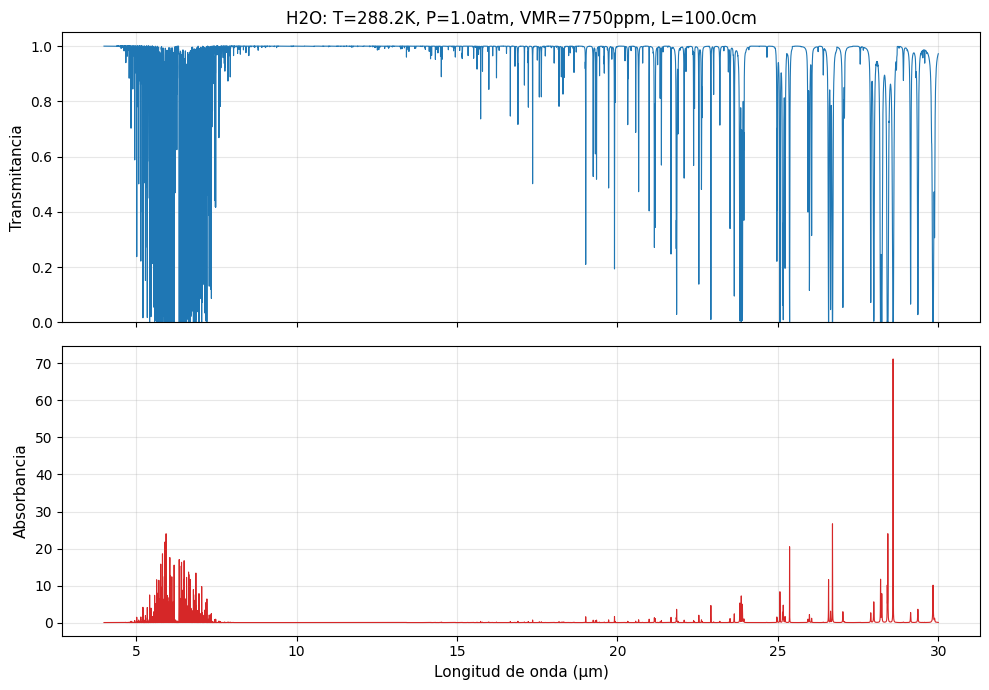

In [31]:
nu_grid, transmitance = transmittanceSpectrum(nu, coef, Environment={'l': longitud_cm})
wavelength_um = 10000.0 / nu_grid  # cm⁻¹ a μm
wavelength_um = wavelength_um[::-1]
transmitance = transmitance[::-1]
absorbance = -np.log(transmitance)

print(f'Estadísticas de Transmitancia:')
print(f'  Mínimo: {transmitance.min():.6f}')
print(f'  Máximo: {transmitance.max():.6f}')
print(f'  Media: {transmitance.mean():.6f}')
print(f'\nEstadísticas de Absorbancia:')
print(f'  Mínimo: {absorbance.min():.6f}')
print(f'  Máximo: {absorbance.max():.6f}')
print(f'  Media: {absorbance.mean():.6f}')
print(f'\nRango de longitud de onda: [{wavelength_um.min():.2f}, {wavelength_um.max():.2f}] μm')

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wavelength_um, transmitance, linewidth=0.8)
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title(f'H2O: T={temperatura}K, P={presion}atm, VMR={vmr*1e6:.0f}ppm, L={longitud_cm}cm', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CO2

In [32]:
vmr = 0.00033
components = [(2, 1, vmr)]  
nu, coef = absorptionCoefficient_HT(
    Components=components,
    SourceTables='CO2_333_2500',
    OmegaRange=(333.33, 2500.0),  
    OmegaStep=0.01,  
    HITRAN_units=False,  
    Environment={'T': temperatura, 'p': presion},
    Diluent={'air': 1.0}
)
print(f'Estadísticas del coeficiente de absorción (cm⁻¹):')
print(f'  Mínimo: {coef.min():.6e}')
print(f'  Máximo: {coef.max():.6e}')
print(f'  Media: {coef.mean():.6e}')
print(f'  Total de puntos espectrales: {len(nu)}')
nu[:5], coef[:5]

{'air': 1.0}
45.251581 seconds elapsed for abscoef; nlines = 68030
Estadísticas del coeficiente de absorción (cm⁻¹):
  Mínimo: 0.000000e+00
  Máximo: 1.307086e-01
  Media: 4.228104e-04
  Total de puntos espectrales: 216668


(array([333.33, 333.34, 333.35, 333.36, 333.37]),
 array([1.77473980e-11, 1.84917608e-11, 1.86626146e-11, 1.82279064e-11,
        1.72679913e-11]))

Estadísticas de Transmitancia:
  Mínimo: 0.000002
  Máximo: 1.000000
  Media: 0.982887

Estadísticas de Absorbancia:
  Mínimo: -0.000000
  Máximo: 13.070865
  Media: 0.042281

Rango de longitud de onda: [4.00, 30.00] μm


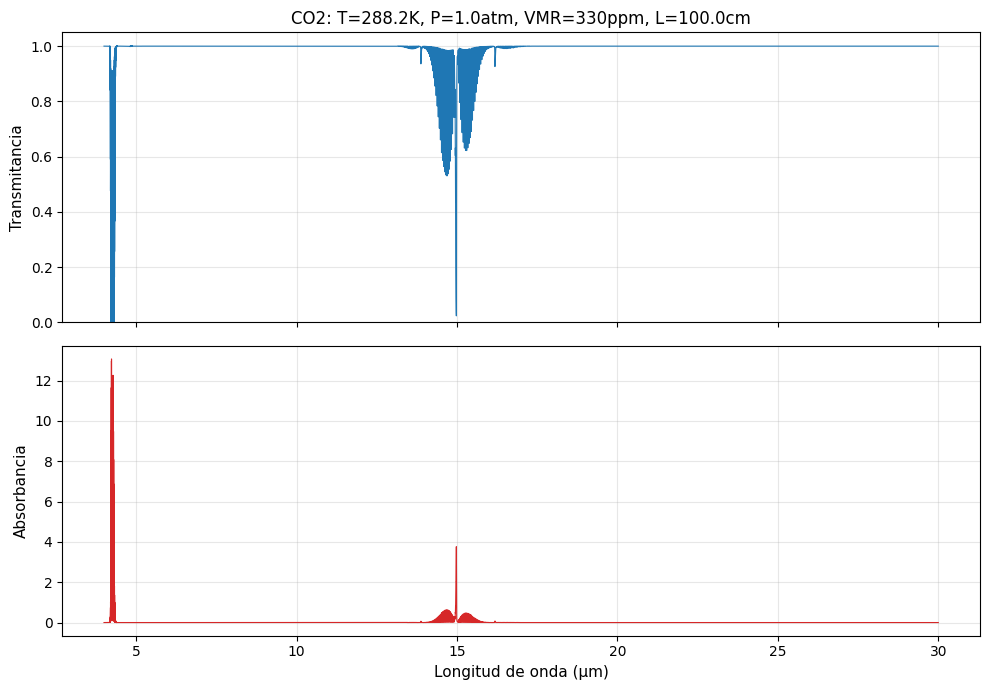

In [33]:
nu_grid, transmitance = transmittanceSpectrum(nu, coef, Environment={'l': longitud_cm})
wavelength_um = 10000.0 / nu_grid  # cm⁻¹ a μm
wavelength_um = wavelength_um[::-1]
transmitance = transmitance[::-1]
absorbance = -np.log(transmitance)

print(f'Estadísticas de Transmitancia:')
print(f'  Mínimo: {transmitance.min():.6f}')
print(f'  Máximo: {transmitance.max():.6f}')
print(f'  Media: {transmitance.mean():.6f}')
print(f'\nEstadísticas de Absorbancia:')
print(f'  Mínimo: {absorbance.min():.6f}')
print(f'  Máximo: {absorbance.max():.6f}')
print(f'  Media: {absorbance.mean():.6f}')
print(f'\nRango de longitud de onda: [{wavelength_um.min():.2f}, {wavelength_um.max():.2f}] μm')

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wavelength_um, transmitance, linewidth=0.8)
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title(f'CO2: T={temperatura}K, P={presion}atm, VMR={vmr*1e6:.0f}ppm, L={longitud_cm}cm', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O3

In [34]:
vmr = 2.66e-08
components = [(3, 1, vmr)]  
nu, coef = absorptionCoefficient_HT(
    Components=components,
    SourceTables='O3_333_2500',
    OmegaRange=(333.33, 2500.0),  
    OmegaStep=0.01,  
    HITRAN_units=False,  
    Environment={'T': temperatura, 'p': presion},
    Diluent={'air': 1.0}
)
print(f'Estadísticas del coeficiente de absorción (cm⁻¹):')
print(f'  Mínimo: {coef.min():.6e}')
print(f'  Máximo: {coef.max():.6e}')
print(f'  Media: {coef.mean():.6e}')
print(f'  Total de puntos espectrales: {len(nu)}')
nu[:5], coef[:5]

{'air': 1.0}
68.724495 seconds elapsed for abscoef; nlines = 173394
Estadísticas del coeficiente de absorción (cm⁻¹):
  Mínimo: 0.000000e+00
  Máximo: 5.067761e-07
  Media: 5.418206e-09
  Total de puntos espectrales: 216668


(array([333.33, 333.34, 333.35, 333.36, 333.37]),
 array([5.54417541e-12, 6.12163964e-12, 6.77139850e-12, 7.49319761e-12,
        8.28323445e-12]))

Estadísticas de Transmitancia:
  Mínimo: 0.999949
  Máximo: 1.000000
  Media: 0.999999

Estadísticas de Absorbancia:
  Mínimo: -0.000000
  Máximo: 0.000051
  Media: 0.000001

Rango de longitud de onda: [4.00, 30.00] μm


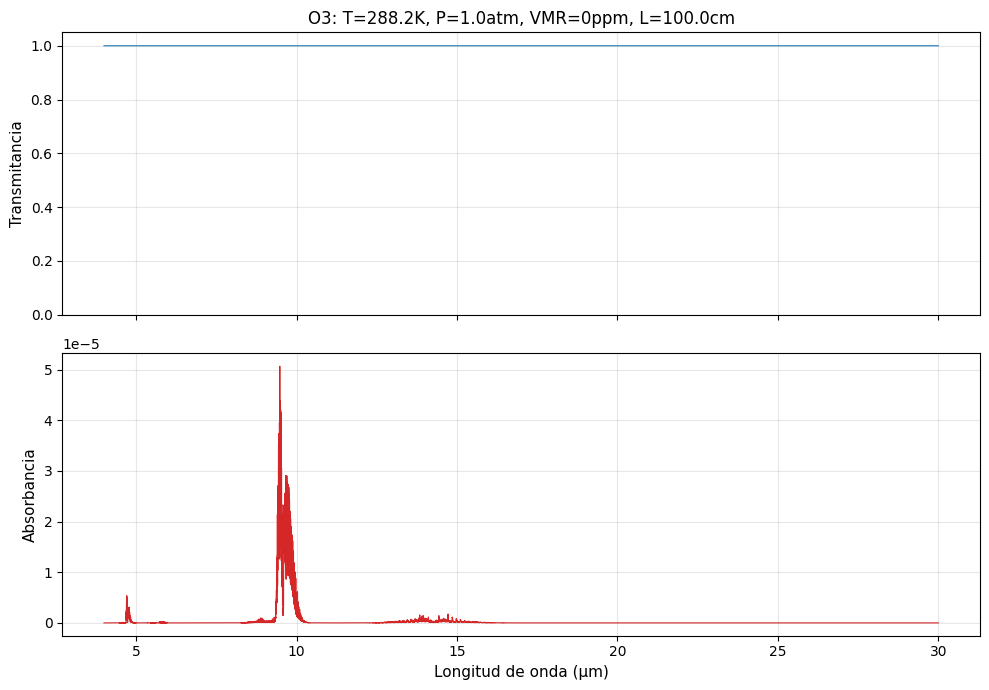

In [35]:
nu_grid, transmitance = transmittanceSpectrum(nu, coef, Environment={'l': longitud_cm})
wavelength_um = 10000.0 / nu_grid  # cm⁻¹ a μm
wavelength_um = wavelength_um[::-1]
transmitance = transmitance[::-1]
absorbance = -np.log(transmitance)

print(f'Estadísticas de Transmitancia:')
print(f'  Mínimo: {transmitance.min():.6f}')
print(f'  Máximo: {transmitance.max():.6f}')
print(f'  Media: {transmitance.mean():.6f}')
print(f'\nEstadísticas de Absorbancia:')
print(f'  Mínimo: {absorbance.min():.6f}')
print(f'  Máximo: {absorbance.max():.6f}')
print(f'  Media: {absorbance.mean():.6f}')
print(f'\nRango de longitud de onda: [{wavelength_um.min():.2f}, {wavelength_um.max():.2f}] μm')

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wavelength_um, transmitance, linewidth=0.8)
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title(f'O3: T={temperatura}K, P={presion}atm, VMR={vmr*1e6:.0f}ppm, L={longitud_cm}cm', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

N2O

In [36]:
vmr = 3.2e-07
components = [(4, 1, vmr)]  
nu, coef = absorptionCoefficient_HT(
    Components=components,
    SourceTables='N2O_333_2500',
    OmegaRange=(333.33, 2500.0),  
    OmegaStep=0.01,  
    HITRAN_units=False,  
    Environment={'T': temperatura, 'p': presion},
    Diluent={'air': 1.0}
)
print(f'Estadísticas del coeficiente de absorción (cm⁻¹):')
print(f'  Mínimo: {coef.min():.6e}')
print(f'  Máximo: {coef.max():.6e}')
print(f'  Media: {coef.mean():.6e}')
print(f'  Total de puntos espectrales: {len(nu)}')
nu[:5], coef[:5]

{'air': 1.0}
47.767367 seconds elapsed for abscoef; nlines = 108041
Estadísticas del coeficiente de absorción (cm⁻¹):
  Mínimo: 0.000000e+00
  Máximo: 3.562104e-05
  Media: 2.546033e-07
  Total de puntos espectrales: 216668


(array([333.33, 333.34, 333.35, 333.36, 333.37]),
 array([2.87559142e-15, 2.99282375e-15, 3.11785448e-15, 3.25139544e-15,
        3.39424063e-15]))

Estadísticas de Transmitancia:
  Mínimo: 0.996444
  Máximo: 1.000000
  Media: 0.999975

Estadísticas de Absorbancia:
  Mínimo: -0.000000
  Máximo: 0.003562
  Media: 0.000025

Rango de longitud de onda: [4.00, 30.00] μm


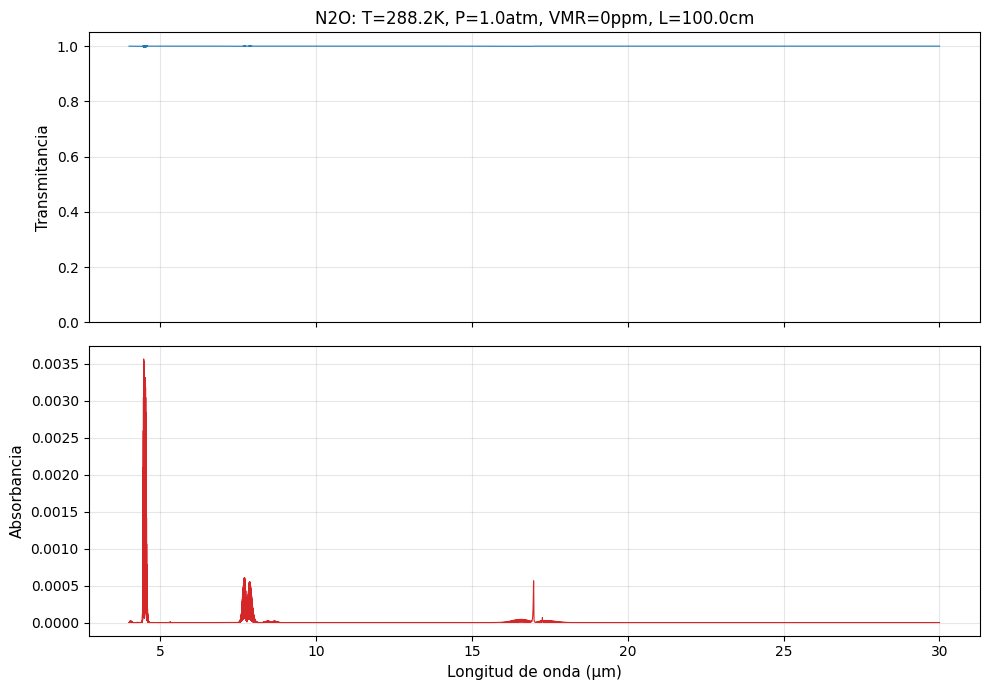

In [37]:
nu_grid, transmitance = transmittanceSpectrum(nu, coef, Environment={'l': longitud_cm})
wavelength_um = 10000.0 / nu_grid  # cm⁻¹ a μm
wavelength_um = wavelength_um[::-1]
transmitance = transmitance[::-1]
absorbance = -np.log(transmitance)

print(f'Estadísticas de Transmitancia:')
print(f'  Mínimo: {transmitance.min():.6f}')
print(f'  Máximo: {transmitance.max():.6f}')
print(f'  Media: {transmitance.mean():.6f}')
print(f'\nEstadísticas de Absorbancia:')
print(f'  Mínimo: {absorbance.min():.6f}')
print(f'  Máximo: {absorbance.max():.6f}')
print(f'  Media: {absorbance.mean():.6f}')
print(f'\nRango de longitud de onda: [{wavelength_um.min():.2f}, {wavelength_um.max():.2f}] μm')

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wavelength_um, transmitance, linewidth=0.8)
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title(f'N2O: T={temperatura}K, P={presion}atm, VMR={vmr*1e6:.0f}ppm, L={longitud_cm}cm', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CO

In [38]:
vmr = 1.5e-07
components = [(5, 1, vmr)]  
nu, coef = absorptionCoefficient_HT(
    Components=components,
    SourceTables='CO_333_2500',
    OmegaRange=(333.33, 2500.0),  
    OmegaStep=0.01,  
    HITRAN_units=False,  
    Environment={'T': temperatura, 'p': presion},
    Diluent={'air': 1.0}
)
print(f'Estadísticas del coeficiente de absorción (cm⁻¹):')
print(f'  Mínimo: {coef.min():.6e}')
print(f'  Máximo: {coef.max():.6e}')
print(f'  Media: {coef.mean():.6e}')
print(f'  Total de puntos espectrales: {len(nu)}')
nu[:5], coef[:5]

{'air': 1.0}
0.165899 seconds elapsed for abscoef; nlines = 282
Estadísticas del coeficiente de absorción (cm⁻¹):
  Mínimo: 0.000000e+00
  Máximo: 9.151362e-06
  Media: 1.796491e-08
  Total de puntos espectrales: 216668


(array([333.33, 333.34, 333.35, 333.36, 333.37]), array([0., 0., 0., 0., 0.]))

Estadísticas de Transmitancia:
  Mínimo: 0.999085
  Máximo: 1.000000
  Media: 0.999998

Estadísticas de Absorbancia:
  Mínimo: -0.000000
  Máximo: 0.000915
  Media: 0.000002

Rango de longitud de onda: [4.00, 30.00] μm


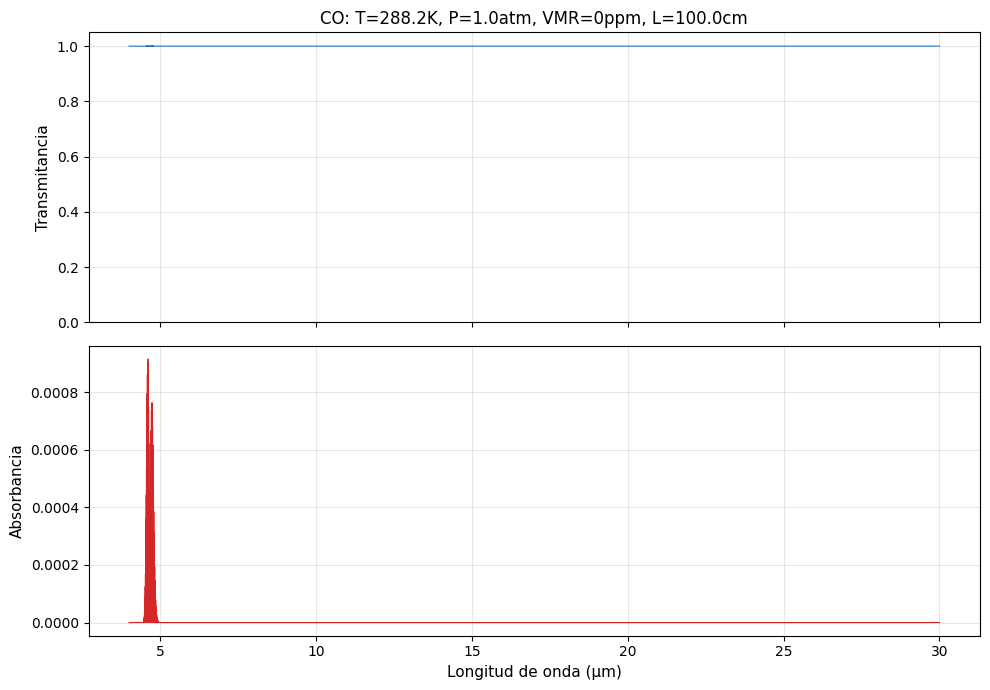

In [39]:
nu_grid, transmitance = transmittanceSpectrum(nu, coef, Environment={'l': longitud_cm})
wavelength_um = 10000.0 / nu_grid  # cm⁻¹ a μm
wavelength_um = wavelength_um[::-1]
transmitance = transmitance[::-1]
absorbance = -np.log(transmitance)

print(f'Estadísticas de Transmitancia:')
print(f'  Mínimo: {transmitance.min():.6f}')
print(f'  Máximo: {transmitance.max():.6f}')
print(f'  Media: {transmitance.mean():.6f}')
print(f'\nEstadísticas de Absorbancia:')
print(f'  Mínimo: {absorbance.min():.6f}')
print(f'  Máximo: {absorbance.max():.6f}')
print(f'  Media: {absorbance.mean():.6f}')
print(f'\nRango de longitud de onda: [{wavelength_um.min():.2f}, {wavelength_um.max():.2f}] μm')

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wavelength_um, transmitance, linewidth=0.8)
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title(f'CO: T={temperatura}K, P={presion}atm, VMR={vmr*1e6:.0f}ppm, L={longitud_cm}cm', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CH4

In [40]:
vmr = 1.7e-06
components = [(6, 1, vmr)]  
nu, coef = absorptionCoefficient_HT(
    Components=components,
    SourceTables='CH4_333_2500',
    OmegaRange=(333.33, 2500.0),  
    OmegaStep=0.01,  
    HITRAN_units=False,  
    Environment={'T': temperatura, 'p': presion},
    Diluent={'air': 1.0}
)
print(f'Estadísticas del coeficiente de absorción (cm⁻¹):')
print(f'  Mínimo: {coef.min():.6e}')
print(f'  Máximo: {coef.max():.6e}')
print(f'  Media: {coef.mean():.6e}')
print(f'  Total de puntos espectrales: {len(nu)}')
nu[:5], coef[:5]

{'air': 1.0}
28.135694 seconds elapsed for abscoef; nlines = 64453
Estadísticas del coeficiente de absorción (cm⁻¹):
  Mínimo: 0.000000e+00
  Máximo: 3.337601e-05
  Media: 1.047935e-07
  Total de puntos espectrales: 216668


(array([333.33, 333.34, 333.35, 333.36, 333.37]),
 array([3.82587523e-14, 4.52518009e-14, 5.30895702e-14, 6.08691046e-14,
        6.70009493e-14]))

Estadísticas de Transmitancia:
  Mínimo: 0.996668
  Máximo: 1.000000
  Media: 0.999990

Estadísticas de Absorbancia:
  Mínimo: -0.000000
  Máximo: 0.003338
  Media: 0.000010

Rango de longitud de onda: [4.00, 30.00] μm


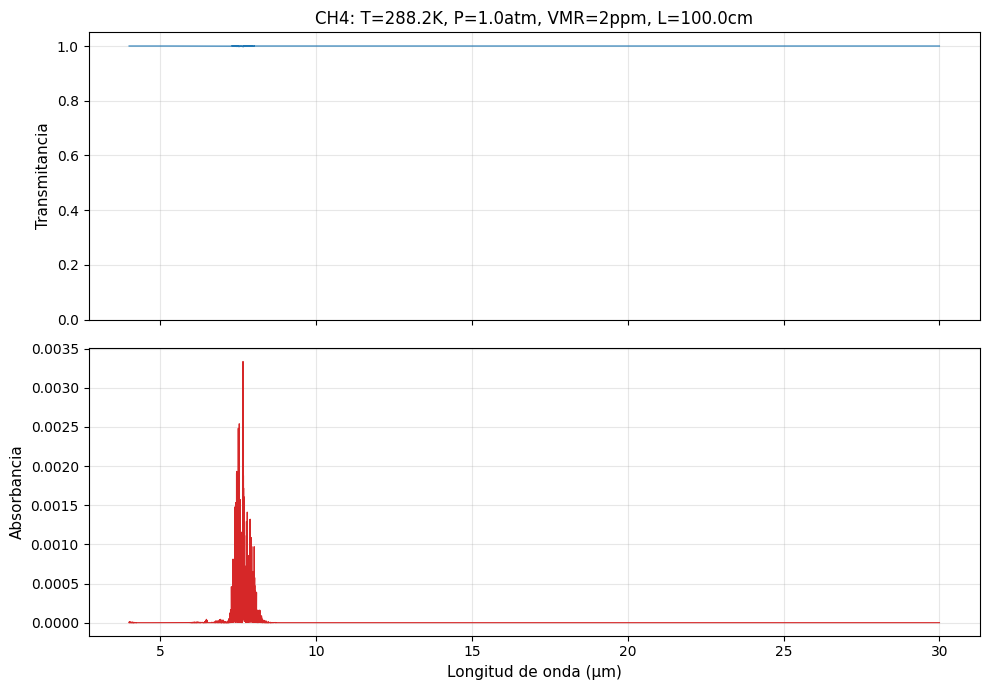

In [41]:
nu_grid, transmitance = transmittanceSpectrum(nu, coef, Environment={'l': longitud_cm})
wavelength_um = 10000.0 / nu_grid  # cm⁻¹ a μm
wavelength_um = wavelength_um[::-1]
transmitance = transmitance[::-1]
absorbance = -np.log(transmitance)

print(f'Estadísticas de Transmitancia:')
print(f'  Mínimo: {transmitance.min():.6f}')
print(f'  Máximo: {transmitance.max():.6f}')
print(f'  Media: {transmitance.mean():.6f}')
print(f'\nEstadísticas de Absorbancia:')
print(f'  Mínimo: {absorbance.min():.6f}')
print(f'  Máximo: {absorbance.max():.6f}')
print(f'  Media: {absorbance.mean():.6f}')
print(f'\nRango de longitud de onda: [{wavelength_um.min():.2f}, {wavelength_um.max():.2f}] μm')

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wavelength_um, transmitance, linewidth=0.8)
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title(f'CH4: T={temperatura}K, P={presion}atm, VMR={vmr*1e6:.0f}ppm, L={longitud_cm}cm', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

{'air': 1.0}
9.736495 seconds elapsed for abscoef; nlines = 16963
{'air': 1.0}
29.565191 seconds elapsed for abscoef; nlines = 68030
{'air': 1.0}
63.350410 seconds elapsed for abscoef; nlines = 173394
{'air': 1.0}
46.853443 seconds elapsed for abscoef; nlines = 108041
{'air': 1.0}
0.149832 seconds elapsed for abscoef; nlines = 282
{'air': 1.0}
25.641467 seconds elapsed for abscoef; nlines = 64453


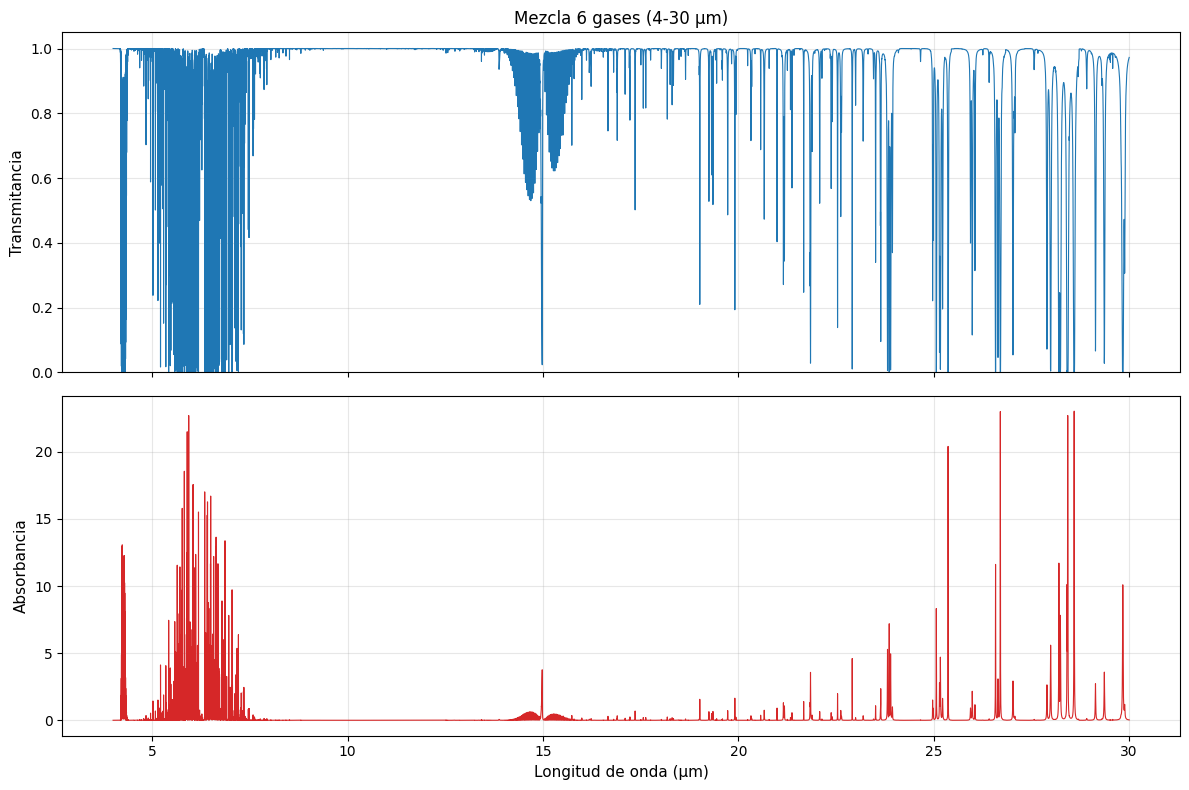


✓ TRANSMITANCIA COMBINADA GUARDADA
  Archivo: ALLGASES_transmitance_333-2500_dnu0.01_T288.2K_P1.000atm_L100cm.npy
  Ruta: C:\Users\PC\Documents\GitHub\Photonix\hapi\signs\ALLGASES_transmitance_333-2500_dnu0.01_T288.2K_P1.000atm_L100cm.npy
  Shape: (2, 216668)


In [43]:
# Firma combinada (6 gases)
nu_min = 333.33
nu_max = 2500.0
dnu = 0.01

Ptotal = 1  # total pressure [atm]
T = 288.2  # temperature [K]
L_m = 1.0  # path length [m]
L_cm = L_m * 100.0

vmr_map = {
    "H2O": 0.00775,
    "CO2": 0.00033,
    "O3": 2.66e-08,
    "N2O": 3.2e-07,
    "CO": 1.5e-07,
    "CH4": 1.7e-06,
}

mol_id_map = {
    "H2O": 1,
    "CO2": 2,
    "O3": 3,
    "N2O": 4,
    "CO": 5,
    "CH4": 6,
}

table_map = {
    name: f"{name}_{int(nu_min)}_{int(nu_max)}" for name in vmr_map
}

nu_base = None
coef_total = None
missing = []

for gas, vmr in vmr_map.items():
    table = table_map[gas]
    if table not in LOCAL_TABLE_CACHE:
        missing.append(table)
        continue
    components = [(mol_id_map[gas], 1, vmr)]
    nu_i, coef_i = absorptionCoefficient_HT(
        Components=components,
        SourceTables=table,
        OmegaRange=(nu_min, nu_max),
        OmegaStep=dnu,
        HITRAN_units=False,
        Environment={'T': T, 'p': Ptotal},
        Diluent={'air': 1.0}
    )
    if nu_base is None:
        nu_base = nu_i
        coef_total = coef_i.copy()
    else:
        if len(nu_i) != len(nu_base) or not np.allclose(nu_i, nu_base):
            coef_i = np.interp(nu_base, nu_i, coef_i)
        coef_total += coef_i

if missing:
    print("Tablas faltantes:")
    for name in missing:
        print(f"  - {name}")

if coef_total is None:
    raise RuntimeError("No se pudo calcular la firma combinada: no hay tablas disponibles.")

nu_grid, transmitance_mix = transmittanceSpectrum(nu_base, coef_total, Environment={'l': L_cm})
wavelength_um = 10000.0 / nu_grid
wavelength_um = wavelength_um[::-1]
transmitance_mix = transmitance_mix[::-1]
absorbance_mix = -np.log(transmitance_mix + 1e-10)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(wavelength_um, transmitance_mix, linewidth=0.8, color='tab:blue')
ax[0].set_ylabel('Transmitancia', fontsize=11)
ax[0].set_title('Mezcla 6 gases (4-30 μm)', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1.05])
ax[1].plot(wavelength_um, absorbance_mix, linewidth=0.8, color='tab:red')
ax[1].set_xlabel('Longitud de onda (μm)', fontsize=11)
ax[1].set_ylabel('Absorbancia', fontsize=11)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

signs_path = Path(r"C:\\Users\\PC\\Documents\\GitHub\\Photonix\\hapi\\signs")
signs_path.mkdir(parents=True, exist_ok=True)
out_name = f"ALLGASES_transmitance_{int(nu_min)}-{int(nu_max)}_dnu{dnu}_T{T:.1f}K_P{Ptotal:.3f}atm_L{L_cm:.0f}cm.npy"
out_path = signs_path / out_name
np.save(str(out_path), np.array([wavelength_um, transmitance_mix]))
print(f"\n✓ TRANSMITANCIA COMBINADA GUARDADA")
print(f"  Archivo: {out_name}")
print(f"  Ruta: {out_path}")
print(f"  Shape: {(2, len(wavelength_um))}")

## 7. Limpieza opcional

Las tablas generadas permanecen en el disco local (`hapi_db`). La función `purge_table` borra el registro en memoria y elimina los archivos `.data` y `.header` correspondientes. Úsala para liberar espacio una vez que exportes o proceses los datos.


In [ ]:
from pathlib import Path

def purge_table(name: str):

    """Elimina la tabla de la caché de HAPI y remueve sus archivos en disco."""
    dropTable(name)
    storage_dir = Path(VARIABLES['BACKEND_DATABASE_NAME'])
    for ext in ('.data', '.header'):
        path = storage_dir / f'{name}{ext}'
        if path.exists():
            path.unlink()
            print(f'Se eliminó {path}')

Se eliminó hapi_db\CO2_window_2016.data
Se eliminó hapi_db\CO2_window_2016.header


In [ ]:
# purge_table('H2O_500_10000')
# purge_table('CO2_2300_2400')
# purge_table('CO2_window_2016')

Se eliminó hapi_db\H2O_500_10000.data
Se eliminó hapi_db\H2O_500_10000.header
